# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs

Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus




### **Libraries**

In [120]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
import ast
from collections import Counter
import seaborn as sns
import shutil
import glob
from tqdm import tqdm
from PIL import Image
import pickle
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

warnings.filterwarnings('ignore')

### **Initial Loading and Simple Preprocessing**

In [121]:
meta_data = pd.read_csv('../input/pannuke/dataset/metadata.csv')
meta_data['category'] = meta_data['category'].str.replace(" ", ",").apply(ast.literal_eval)
meta_data = meta_data.dropna(subset=['tissue'])

meta_data['fold'] = meta_data['file_path'].str[5]
meta_data['file_path'] = meta_data['file_path'].str[:-10]

tissue_mapping = {
    0: "Adrenal Gland",
    1: "Bile Duct",
    2: "Bladder",
    3: "Breast",
    4: "Cervix",
    5: "Colon",
    6: "Esophagus",
    7: "Head & Neck",
    8: "Kidney",
    9: "Liver",
    10: "Lung",
    11: "Ovarian",
    12: "Pancreatic",
    13: "Prostate",
    14: "Skin",
    15: "Stomach",
    16: "Testis",
    17: "Thyroid",
    18: "Uterus"
}

meta_data['tissue_labels'] = meta_data['tissue'].astype(int).map(tissue_mapping)

meta_data.sample(5)

,file_path,category,tissue,fold,tissue_labels
4582,fold_2/sample_1926,"[4, 4, 4, 4, 4, 4, 4]",7,2,Head & Neck
1599,fold_1/sample_1599,"[2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, ...",1,1,Bile Duct
4472,fold_2/sample_1816,"[0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",6,2,Esophagus
7717,fold_3/sample_2538,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",18,3,Uterus
7756,fold_3/sample_2577,"[1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",18,3,Uterus


### **PathopixGANs Pipeline**

#### **Extracting Dead Category Cells**

In [122]:
neoplastic_cells_df = meta_data[meta_data['category'].apply(lambda x: 0 in x)]
inflammatory_cells_df = meta_data[meta_data['category'].apply(lambda x: 1 in x)]
connective_cells_df = meta_data[meta_data['category'].apply(lambda x: 2 in x)]
dead_cells_df = meta_data[meta_data['category'].apply(lambda x: 3 in x)]
epithelial_cells_df = meta_data[meta_data['category'].apply(lambda x: 4 in x)]

neoplastic_cells_df.to_csv('neoplastic_cells_df.csv', index=False)
inflammatory_cells_df.to_csv('inflammatory_cells_df.csv', index=False)
connective_cells_df.to_csv('connective_cells_df.csv', index=False)
dead_cells_df.to_csv('dead_cells_df.csv', index=False)
epithelial_cells_df.to_csv('epithelial_cells_df.csv', index=False)

dead_cells_df.head()

,file_path,category,tissue,fold,tissue_labels
178,fold_1/sample_178,"[1, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",3,1,Breast
776,fold_1/sample_776,"[1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3]",5,1,Colon
782,fold_1/sample_782,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",5,1,Colon
784,fold_1/sample_784,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,1,Colon
790,fold_1/sample_790,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,1,Colon


#### **Merging Masks**

In [123]:
def load_images_and_merge_masks(dataset_path, df, category = 3):
    image_mask_dict = {}  

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Samples"):
        sample_path = os.path.join(dataset_path, row["file_path"])

        image_path = os.path.join(sample_path, "image.png")
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue
        image = cv2.imread(image_path)  

        mask_dir = os.path.join(sample_path, "masks")
        if not os.path.exists(mask_dir):
            print(f"Mask directory not found: {mask_dir}")
            continue

        merged_mask = None
        for mask_filename in os.listdir(mask_dir):
            if mask_filename.startswith(f"mask_{category}_"):  
                mask_path = os.path.join(mask_dir, mask_filename)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  

                if merged_mask is None:
                    merged_mask = mask  
                else:
                    merged_mask = cv2.bitwise_or(merged_mask, mask)  

        if merged_mask is not None:
            image_mask_dict[sample_path] = (image, merged_mask)  

    return image_mask_dict

In [124]:
DATASET_PATH = "../input/pannuke/dataset"

dead_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, dead_cells_df, 3)

if False:
    neoplastic_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, neoplastic_cells_df, 0)
    inflammatory_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, inflammatory_cells_df, 1)
    connective_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, connective_cells_df, 2)
    epithelial_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, epithelial_cells_df, 4)

Processing Samples: 100%|██████████| 232/232 [00:08<00:00, 27.48it/s]


In [125]:
if False:
    dictionaries = {
        "neoplastic_image_mask_dict.pkl": neoplastic_image_mask_dict,
        "inflammatory_image_mask_dict.pkl": inflammatory_image_mask_dict,
        "connective_image_mask_dict.pkl": connective_image_mask_dict,
        "dead_image_mask_dict.pkl": dead_image_mask_dict,
        "epithelial_image_mask_dict.pkl": epithelial_image_mask_dict,
    }
    
    for filename, data in dictionaries.items():
        with open(filename, "wb") as f:
            pickle.dump(data, f)

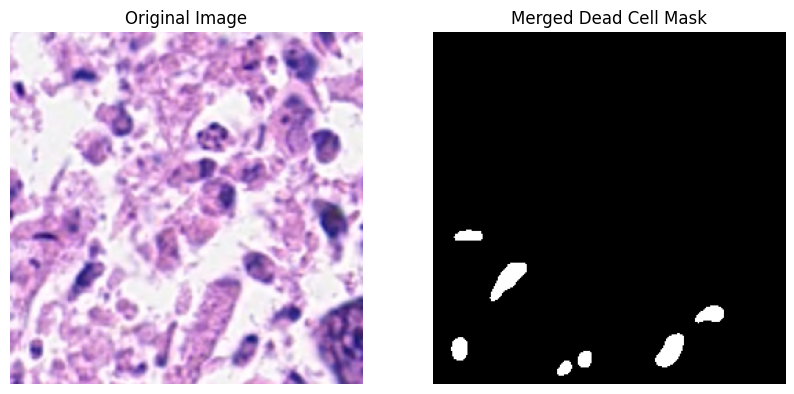

In [126]:
if dead_image_mask_dict:
    sample_path = '../input/pannuke/dataset/fold_1/sample_776'
    (sample_image, sample_mask) = dead_image_mask_dict[sample_path]
    
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))  
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(sample_mask, cmap="gray")  
    plt.title("Merged Dead Cell Mask")
    plt.axis("off")

    plt.show()

#### **Loading data using `Torch.DataLoader`**

In [127]:

class CellDataset(Dataset):
    def __init__(self, image_mask_dict, transform=None):
        self.image_mask_pairs = list(image_mask_dict.values())
        self.transform = transform

    def __len__(self):
        return len(self.image_mask_pairs)

    def __getitem__(self, idx):
        image, mask = self.image_mask_pairs[idx]

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        image = torch.tensor(image).permute(2, 0, 1)  
        mask = torch.tensor(mask).unsqueeze(0)  

        return image, mask

with open("dead_image_mask_dict.pkl", "rb") as f:
    dead_image_mask_dict = pickle.load(f)

dataset = CellDataset(dead_image_mask_dict)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

for img, mask in dataloader:
    print(f"Image shape: {img.shape}, Mask shape: {mask.shape}")
    break

Image shape: torch.Size([8, 3, 256, 256]), Mask shape: torch.Size([8, 1, 256, 256])


#### **Spacially Adaptive Normalization**

In [128]:
class SPADE(nn.Module):
    def __init__(self, norm_nc, label_nc):
        super().__init__()
        self.param_free_norm = nn.BatchNorm2d(norm_nc, affine=False)

        self.mlp_shared = nn.Sequential(
            nn.Conv2d(label_nc, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.mlp_gamma = nn.Conv2d(128, norm_nc, kernel_size=3, padding=1)
        self.mlp_beta = nn.Conv2d(128, norm_nc, kernel_size=3, padding=1)

    def forward(self, x, segmap):
        normalized = self.param_free_norm(x)
        segmap = F.interpolate(segmap, size=x.shape[2:], mode='nearest')
        actv = self.mlp_shared(segmap)
        gamma = self.mlp_gamma(actv)
        beta = self.mlp_beta(actv)
        return normalized * (1 + gamma) + beta

#### **PathopixGAN ResBlock**

In [129]:
class PathopixGANResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, label_nc):
        super().__init__()
        self.spade1 = SPADE(in_channels, label_nc)
        self.gelu1 = nn.GELU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.spade2 = SPADE(out_channels, label_nc)
        self.gelu2 = nn.GELU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, segmap):
        x = self.spade1(x, segmap)
        x = self.gelu1(x)
        x = self.conv1(x)

        x = self.spade2(x, segmap)
        x = self.gelu2(x)
        x = self.conv2(x)

        return x

#### **PathopixGAN Generator**

In [145]:
class PathopixGANGenerator(nn.Module):
    def __init__(self, nz, label_nc):
        super().__init__()
        self.fc = nn.ConvTranspose2d(nz, 1024, 4, 1, 0)  # Latent vector to 4x4

        self.res1 = PathopixGANResBlock(1024, 512, label_nc)
        self.upsample1 = nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1)  # 4x4 -> 8x8
        
        self.res2 = PathopixGANResBlock(512, 256, label_nc)
        self.upsample2 = nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1)  # 8x8 -> 16x16
        
        self.res3 = PathopixGANResBlock(256, 128, label_nc)
        self.upsample3 = nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1)  # 16x16 -> 32x32
        
        self.res4 = PathopixGANResBlock(128, 64, label_nc)
        self.upsample4 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1)  # 32x32 -> 64x64
        
        self.upsample5 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1)  # 64x64 -> 128x128
        self.upsample6 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1)  # 128x128 -> 256x256

        self.final_conv = nn.Conv2d(64, 3, kernel_size=3, padding=1)  # Final RGB image
        self.tanh = nn.Tanh()

    def forward(self, z, segmap):
        x = self.fc(z)
        x = self.res1(x, segmap)
        x = self.upsample1(x)
        
        x = self.res2(x, segmap)
        x = self.upsample2(x)
        
        x = self.res3(x, segmap)
        x = self.upsample3(x)

        x = self.res4(x, segmap)
        x = self.upsample4(x)

        x = self.upsample5(x)
        x = self.upsample6(x)

        x = self.final_conv(x)
        return self.tanh(x)

#### **PatchGAN Discriminator**

In [143]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=3):
        super(PatchGANDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),  # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=3, stride=1, padding=1),  # 8 -> 8 (SAFE)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

#### **Training**

In [153]:
device = "cuda" if torch.cuda.is_available() else "cpu"

nz = 100  
label_nc = 1

G = PathopixGANGenerator(nz, label_nc).to(device)
D = PatchGANDiscriminator(3).to(device)

optimizer_G = optim.Adam(G.parameters(), lr=0.002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.002, betas=(0.5, 0.999))

criterion = nn.BCEWithLogitsLoss()

num_epochs = 50
for epoch in range(num_epochs):
    for batch_idx, (images, masks) in enumerate(dataloader):

        images, masks = images.to(device), masks.to(device)
        batch_size = images.size(0)

        D.zero_grad()
        real_labels = torch.ones((batch_size, 1, 8, 8), device=device)
        fake_labels = torch.zeros((batch_size, 1, 8, 8), device=device)

        outputs_real = D(images)

        real_labels = torch.ones_like(outputs_real)
        loss_real = criterion(outputs_real, real_labels)

        z = torch.randn(batch_size, nz, 1, 1, device=device)

        fake_images = G(z, masks)

        outputs_fake = D(fake_images.detach())

        loss_fake = criterion(outputs_fake, fake_labels)
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()


        G.zero_grad()
        outputs_fake = D(fake_images)
        loss_G = criterion(outputs_fake, real_labels)
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] Complete | Loss D: {round(loss_D.item(),2)} | Loss G: {round(loss_G.item(), 2)}")

29it [00:06,  4.75it/s]


Epoch [1/50] Complete | Loss D: 1.01 | Loss G: 0.69


29it [00:06,  4.65it/s]


Epoch [2/50] Complete | Loss D: 1.01 | Loss G: 0.69


29it [00:06,  4.56it/s]


...

Epoch [48/50] Complete | Loss D: 1.01 | Loss G: 0.69


29it [00:05,  4.86it/s]


Epoch [49/50] Complete | Loss D: 1.01 | Loss G: 0.69


29it [00:05,  4.88it/s]

Epoch [50/50] Complete | Loss D: 1.01 | Loss G: 0.69


#### **Synthetic Image**

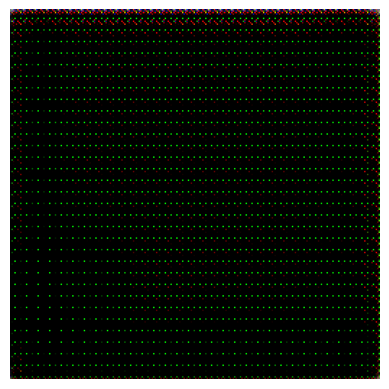

In [165]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Load a real mask image
mask_path = "../input/pannuke/dataset/fold_1/sample_0/masks/mask_0_2.png"  # Update this with the actual path
mask_image = Image.open(mask_path).convert("L")  # Convert to grayscale if needed

# Transform the mask to match input size & format
mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),   # Resize to match generator input
    transforms.ToTensor(),           # Convert to tensor (0-1 range)
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] (same as training)
])

real_mask = mask_transform(mask_image).unsqueeze(0).to("cuda")  # Add batch dim & move to GPU

# Generate image using the real mask
G.eval()
nz = 100
z = torch.randn(1, nz, 1, 1, device="cuda")  # Random latent vector

with torch.no_grad():
    fake_image = G(z, real_mask).cpu()

# Convert image to displayable format
fake_image = (fake_image * 0.5) + 0.5  # De-normalize to [0,1]
fake_image = fake_image.squeeze(0).permute(1, 2, 0).numpy()

# Show the generated image
plt.imshow(fake_image)
plt.axis("off")
plt.show()